In [5]:
from pathlib import Path

import einops
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ml_tools as mlt
import sim_ranking as sr

In [29]:
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/db/gm_db_neil.sqlite")
db = sr.db.DB(db_ffp)

In [30]:
im_data = db.get_sim_data("3468575", ["CCCC"])

In [31]:
im_data

,rel_id,site_id,data_source,PGA,PGV,AI,CAV,Ds575,Ds595,pSA_0.01,...,pSA_1.25,pSA_1.5,pSA_2.0,pSA_2.5,pSA_3.0,pSA_4.0,pSA_5.0,pSA_6.0,pSA_7.5,pSA_10.0
record_id,,,,,,,,,,,,,,,,,,,,,
3468575_CCCC_REL31,REL31,CCCC,specific,0.292433,28.630919,109.284073,0.784706,5.8650,8.6650,0.293671,...,0.269973,0.222496,0.209694,0.143516,0.103776,0.041923,0.023193,0.015557,0.010113,0.006009
3468575_CCCC_REL26,REL26,CCCC,specific,0.315315,45.112970,134.747209,0.816012,4.0750,7.1675,0.316154,...,0.348320,0.323894,0.240167,0.152239,0.121413,0.058863,0.030021,0.018894,0.010941,0.005542
3468575_CCCC_REL91,REL91,CCCC,specific,0.353708,42.794295,171.670961,0.884326,3.9950,5.9025,0.354323,...,0.535239,0.296885,0.210052,0.208400,0.164389,0.080239,0.045490,0.029210,0.017275,0.008934
3468575_CCCC_REL59,REL59,CCCC,specific,0.332561,53.994172,188.100705,1.034412,4.7450,7.4050,0.333090,...,0.509478,0.498772,0.505754,0.417467,0.228188,0.076316,0.047962,0.034283,0.021284,0.012342
3468575_CCCC_REL99,REL99,CCCC,specific,0.332576,31.783574,137.193665,0.834181,5.0625,7.8825,0.333152,...,0.406813,0.221466,0.180532,0.138668,0.115470,0.050661,0.035727,0.027542,0.018743,0.009436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3468575_CCCC_REL54,REL54,CCCC,specific,0.293618,53.353256,150.132203,0.853437,4.8175,6.6300,0.293862,...,0.837902,0.511847,0.175611,0.134705,0.109545,0.053392,0.036528,0.025550,0.015974,0.008431
3468575_CCCC_REL19,REL19,CCCC,specific,0.289448,39.828154,128.060114,0.955625,6.2200,10.2200,0.291353,...,0.322812,0.322227,0.222763,0.156824,0.114459,0.063741,0.037795,0.029448,0.018904,0.010047
3468575_CCCC_REL90,REL90,CCCC,specific,0.317910,39.655787,109.362469,0.792037,4.6275,8.0575,0.319892,...,0.306680,0.288229,0.249691,0.263619,0.173676,0.058478,0.033067,0.028198,0.021856,0.012963


(0.0, 1.4)

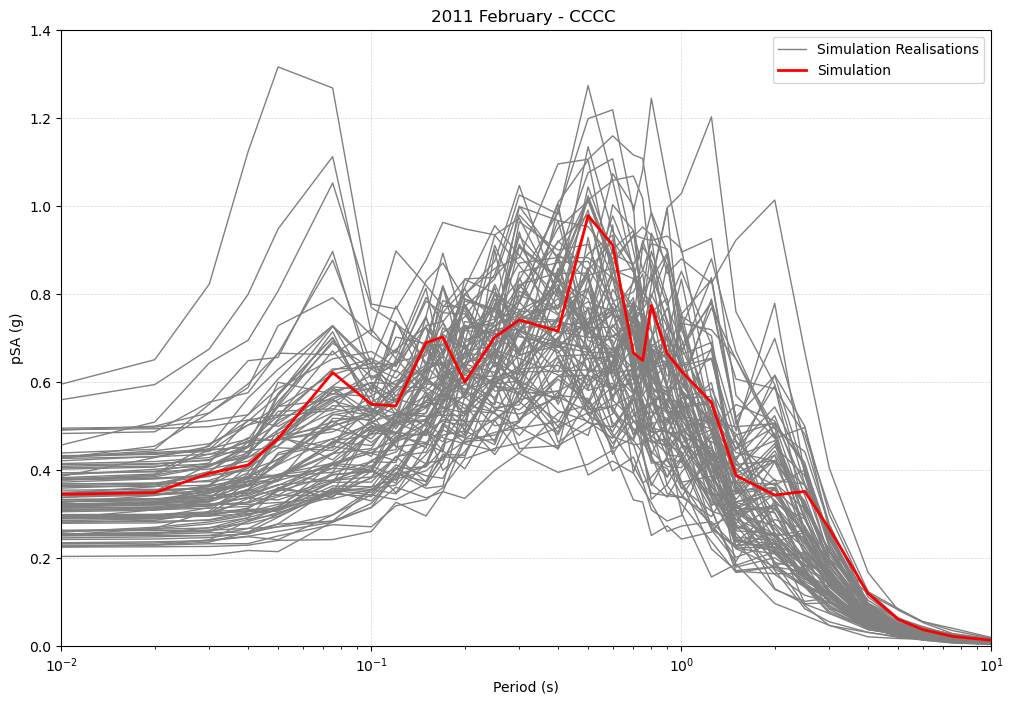

In [54]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.semilogx(np.tile(np.asarray(sr.constants.PERIODS)[None, :], (100, 1)).T, im_data[sr.constants.PSA_KEYS].T, c="gray", linewidth=1)
ax.semilogx(sr.constants.PERIODS, im_data[sr.constants.PSA_KEYS].iloc[5, :], linewidth=2, c="r", label="Simulation")

ax.set_title(f"2011 February - CCCC ")
ax.set_xlabel(f"Period (s)")
ax.set_ylabel(f"pSA (g)")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.legend([plt.Line2D([0], [0], color="gray", lw=1),
           plt.Line2D([0], [0], color="red", lw=2)], ["Simulation Realisations", "Simulation"])

ax.set_xlim(0.01, 10)
ax.set_ylim(0, 1.4)


(0.01, 10)

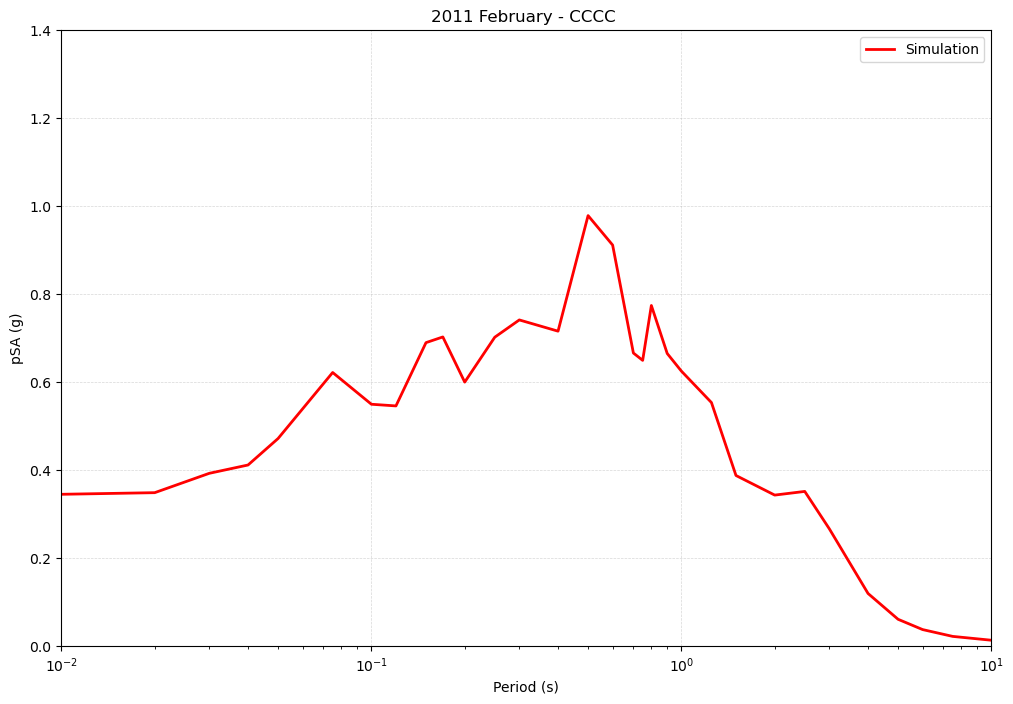

In [53]:
fig, ax = plt.subplots(figsize=(12, 8))

# ax.semilogx(np.tile(np.asarray(sr.constants.PERIODS)[None, :], (100, 1)).T, im_data[sr.constants.PSA_KEYS].T, c="gray", linewidth=1)
ax.semilogx(sr.constants.PERIODS, im_data[sr.constants.PSA_KEYS].iloc[5, :], linewidth=2, c="r", label="Simulation")

ax.set_title(f"2011 February - CCCC ")
ax.set_xlabel(f"Period (s)")
ax.set_ylabel(f"pSA (g)")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.legend([
	# plt.Line2D([0], [0], color="gray", lw=1),
	plt.Line2D([0], [0], color="red", lw=2)
], [
	# "Simulation Realisation", 
	"Simulation"
])

ax.set_ylim(0, 1.4)
ax.set_xlim(0.01, 10)


In [3]:
emp_cim_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/emp_cIM_perturbed_100r") 
ml_data_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0616_1423_lb_20_100_SCweighted_probL2_0p5")

def load_cim_data(data_dir: Path, event: str):
	result_ffp = data_dir / event / "empirical_cMVN/cMVN_distributions.pickle"
	return sr.conditional.ConditionalMVNDistribution.load(result_ffp)

db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")


In [6]:
meta = mlt.utils.load_yaml(ml_data_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

sc_sum_df = pd.read_parquet(ml_data_dir / "val_scenario_summary.parquet")
sc_df = pd.read_parquet(ml_data_dir / "val_scenario_results.parquet")

db = sr.db.DB(db_ffp)


In [7]:
## Compute residuals
ml_obs_residuals = sr.ml.sc_prob.compute_ml_residuals_wrt_obs(sc_sum_df, db_ffp, run_config.ims)

emp_cIM_obs_residuals = sr.ml.sc_prob.compute_cIM_residuals_wrt_obs(emp_cim_dir, db_ffp, sr.constants.RankingMethod.emp_cMVN, run_config.ims)

Skipping event 2016p858913 as no cIM data found
Skipping event 2016p886502 as no cIM data found


In [8]:
# Make sure data matches
ml_obs_residuals = ml_obs_residuals.loc[np.isin(ml_obs_residuals.event_id, emp_cIM_obs_residuals.event_id)]
sc_sum_df = sc_sum_df.loc[np.isin(sc_sum_df.event_id, emp_cIM_obs_residuals.event_id)]

In [9]:
# Only interested in scenarios where both ML and empirical cIM have been computed
emp_cIM_obs_residuals = emp_cIM_obs_residuals.loc[ml_obs_residuals.index]
assert np.all(sc_sum_df.index == ml_obs_residuals.index)
assert np.all(emp_cIM_obs_residuals.index == ml_obs_residuals.index)

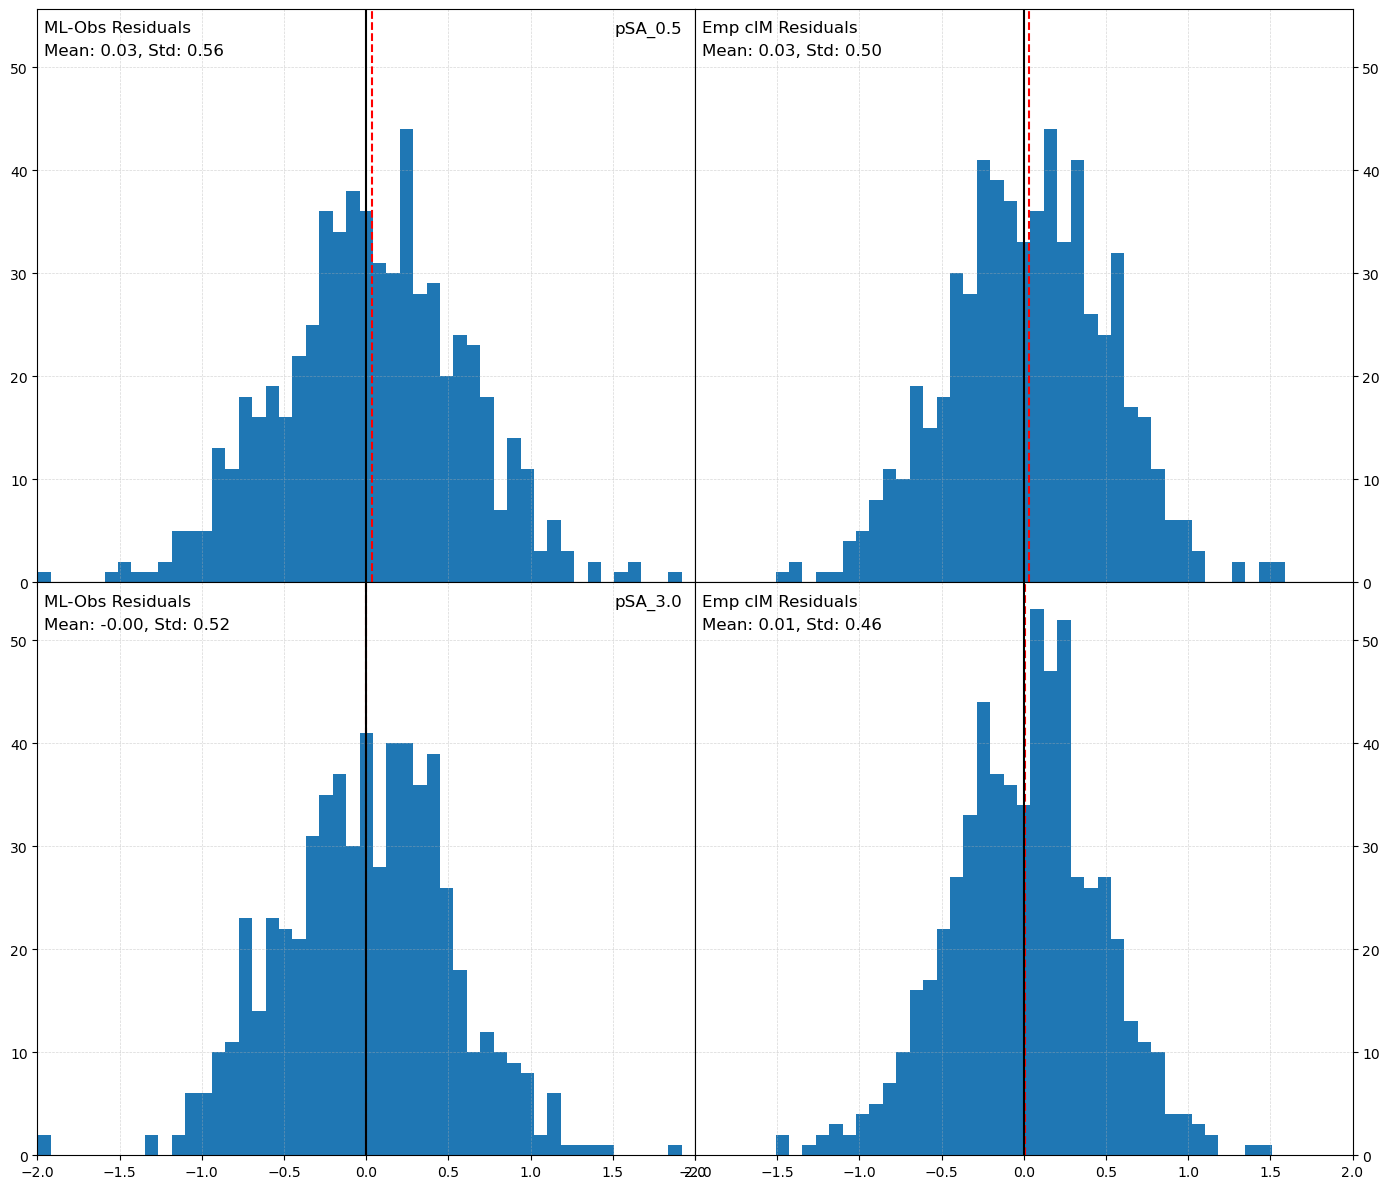

In [29]:
ims = ["pSA_0.5", "pSA_3.0"]

n_rows = len(ims)
fig, axs = plt.subplots(n_rows, 2, figsize=(14, n_rows * 6), sharex=True)

bins = np.linspace(-2.0, 2.0, 50)

y_max = 0
for ix, (cur_im, (cur_ax1, cur_ax2)) in enumerate(zip(ims, axs)):
    cur_ax1.hist(ml_obs_residuals[cur_im].values, bins=bins)
    cur_ax1.axvline(
        np.mean(ml_obs_residuals[cur_im].values), color="r", linestyle="--"
    )
    cur_ax1.axvline(0, color="k", linestyle="-")
    cur_ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")

    cur_ax2.hist(emp_cIM_obs_residuals[cur_im].values, bins=bins)
    cur_ax2.axvline(
        np.mean(emp_cIM_obs_residuals[cur_im].values),
        color="r",
        linestyle="--",
    )
    cur_ax2.axvline(0, color="k", linestyle="-")
    cur_ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")

    # cur_ax3.hist(sim_cIM_obs_residuals[cur_im].values, bins=bins)
    # cur_ax3.axvline(
    #     np.mean(sim_cIM_obs_residuals[cur_im].values),
    #     color="r",
    #     linestyle="--",
    # )
    # cur_ax3.axvline(0, color="k", linestyle="-")
    # cur_ax3.grid(linewidth=0.5, alpha=0.5, linestyle="--")

    if ix == 0:
        cur_ax1.set_xlim(-2.0, 2.0)

    y_max = max(y_max, cur_ax1.get_ylim()[1], cur_ax2.get_ylim()[1])

    cur_ax2.yaxis.tick_right()

    cur_ax1.text(
        0.01,
        0.98,
        f"ML-Obs Residuals",
        horizontalalignment="left",
        verticalalignment="top",
        transform=cur_ax1.transAxes,
        fontsize=12,
    )
    cur_ax1.text(
        0.98,
        0.98,
        f"{cur_im}",
        horizontalalignment="right",
        verticalalignment="top",
        transform=cur_ax1.transAxes,
        fontsize=12,
    )
    cur_ax1.text(
        0.01,
        0.94,
        f"Mean: {np.mean(ml_obs_residuals[cur_im].values):.2f}, Std: {np.std(ml_obs_residuals[cur_im].values):.2f}",
        horizontalalignment="left",
        verticalalignment="top",
        transform=cur_ax1.transAxes,
        fontsize=12,
    )

    cur_ax2.text(
        0.01,
        0.98,
        f"Emp cIM Residuals",
        horizontalalignment="left",
        verticalalignment="top",
        transform=cur_ax2.transAxes,
        fontsize=12,
    )
    cur_ax2.text(
        0.01,
        0.94,
        f"Mean: {np.mean(emp_cIM_obs_residuals[cur_im].values):.2f}, Std: {np.std(emp_cIM_obs_residuals[cur_im].values):.2f}",
        horizontalalignment="left",
        verticalalignment="top",
        transform=cur_ax2.transAxes,
        fontsize=12,
    )

    # cur_ax3.text(
    #     0.01,
    #     0.98,
    #     f"Sim cIM Residuals",
    #     horizontalalignment="left",
    #     verticalalignment="top",
    #     transform=cur_ax3.transAxes,
    #     fontsize=12,
    # )
    # cur_ax3.text(
    #     0.01,
    #     0.94,
    #     f"Mean: {np.mean(sim_cIM_obs_residuals[cur_im].values):.2f}, Std: {np.std(sim_cIM_obs_residuals[cur_im].values):.2f}",
    #     horizontalalignment="left",
    #     verticalalignment="top",
    #     transform=cur_ax3.transAxes,
    #     fontsize=12,
    # )

for cur_ax in axs.ravel():
    cur_ax.set_ylim(0, y_max)

fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
# st.pyplot(fig, use_container_width=False)

In [18]:
axs

array([<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >],
      dtype=object)

In [14]:
ml_obs_residuals[im]

3366933_HVSC       -0.222154
3366933_LINC        0.135135
3366933_ROLC        0.587319
3366933_SPFS        0.470018
2013p614268_ARKS   -0.291183
                      ...   
2016p118944_PARS   -0.042886
2016p118944_RCBS    0.586559
2016p118944_ROLC   -0.887825
2016p118944_SCAC    0.809567
2016p118944_STKS   -0.176082
Name: pSA_3.0, Length: 605, dtype: float64